In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [108]:
test_frame = pd.read_csv('./datasets/titanic/test.csv')
frame = pd.read_csv('./datasets/titanic/train.csv')
test_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [109]:
frame['Fare'] = np.log(frame['Fare'] + 1)
frame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,2.639057,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,3.433987,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,3.196630,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,3.433987,C148,C


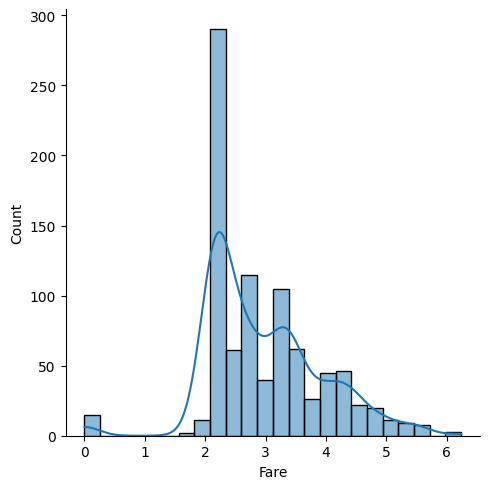

In [114]:
sns.displot(frame["Fare"], kde=True)

<Axes: >

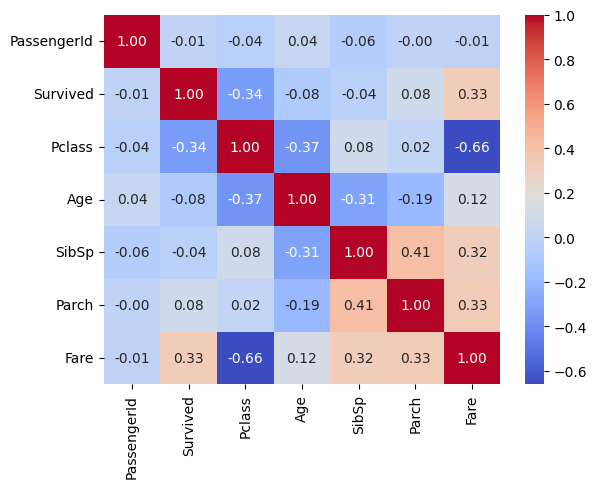

In [115]:
corr = frame.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

In [62]:
frame.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
frame.isnull().sum()
frame.fillna({'Age': frame['Age'].median()}, inplace=True)
frame.fillna({'Embarked': frame['Embarked'].mode()}, inplace=True)

frame = pd.get_dummies(frame, columns=['Sex', 'Embarked'], drop_first=True)
frame

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,28.0,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False


In [65]:
X = frame.drop('Survived', axis=1)
y = frame['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

X_scaled_train

array([[-1.61413602,  1.25364106, -0.47072241, ...,  0.7243102 ,
        -0.30335547,  0.59681695],
       [-0.40055118, -0.47728355, -0.47072241, ...,  0.7243102 ,
        -0.30335547,  0.59681695],
       [ 0.81303367,  0.21508629, -0.47072241, ...,  0.7243102 ,
        -0.30335547,  0.59681695],
       ...,
       [ 0.81303367,  0.90745614,  1.23056874, ...,  0.7243102 ,
        -0.30335547,  0.59681695],
       [-1.61413602, -1.1696534 ,  0.37992316, ..., -1.38062393,
        -0.30335547,  0.59681695],
       [-1.61413602, -0.63114352, -0.47072241, ...,  0.7243102 ,
        -0.30335547,  0.59681695]], shape=(712, 8))

In [94]:
classifier = RandomForestClassifier(random_state = 42).fit(X_scaled_train, y_train)

classifier.score(X_scaled_test, y_test)
predict = classifier.predict(X_scaled_test)

accuracy = accuracy_score(predict, y_test)
accuracy

0.8212290502793296

In [92]:
score = cross_val_score(classifier, X, y, cv = 5)
score.mean()

np.float64(0.6835666310966041)

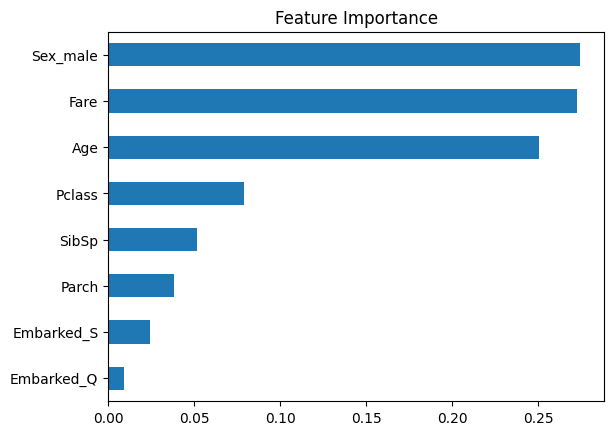

In [95]:
feat_imp = pd.Series(classifier.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()


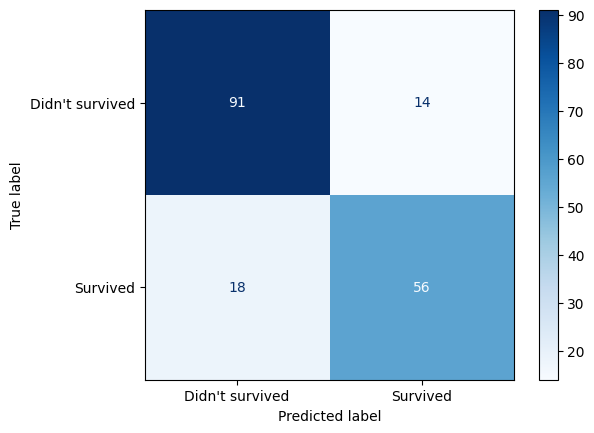

In [104]:
cm = confusion_matrix(y_test, predict, labels=[0,1])
display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Didn't survived", "Survived"])
display.plot(cmap='Blues')
plt.show()

Note: you may need to restart the kernel to use updated packages.
